In [2]:
# Import required libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# statsmodels is the standard library for detailed regression analysis in Python
import statsmodels.api as sm

%matplotlib inline

In [3]:
# Now we are going to load the auto mpg dataset
df = pd.read_csv('./data/auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
# View summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


After view the summary as you can see there are 7 Numerical variables and 2 categoricla variables (Horsepower and Car name).

In [5]:
# Checking any missing values
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

So right now as you can see there is no missing values in Auto_MPG Dataset.Now we are going to further check if there is value stored as '?' or not.

In [6]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

After checking the unique values, we found that there is one unique value ('?') which was hidden when I checked the missing value, so now i am going to handle it.

In [7]:
# Replace ? with NaN 
df['horsepower'] = df['horsepower'].replace('?',np.nan)

In [8]:
df['horsepower'] = pd.to_numeric(df['horsepower'],errors="coerce")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [10]:
# drop rows any missing value in any columns
df.dropna(inplace=True)

In [11]:
df.shape

(392, 9)

## Visualization

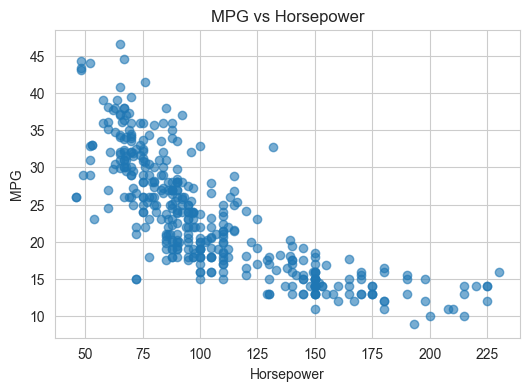

In [13]:
# Visualise a scatter plot between MPG vs Horsepower
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'],df['mpg'],alpha=0.6)
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower')
plt.show()

**Curvature**

Notice how there is a bit of a curve, if you were to draw a "best fit" line?

To get non-straight lines we'll need to introduce polynomial terms.

In [19]:
# using the OLS method that is like an equation mpg ~ horsepower
X = df['horsepower']
Y = df['mpg']
# Add a constant to the independent variable, this is required for statsmodels to calculate the intercept
X_with_const = sm.add_constant(X)
model_hp = sm.OLS(Y,X_with_const).fit()
print(model_hp.summary())



                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        11:51:58   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

## Linear Regression Modelling with MPG as Target Var. & horsepower^2 as Predictor Variable

In [14]:
# create an X with horsepower and horsepower squared to capture non-linear relationship
X = df['horsepower']
X_squared = X**2
X = pd.DataFrame({'horsepower': X, 'horsepower_squared': X_squared})
Y = df['mpg']

X.head()



,horsepower,horsepower_squared
0,130.0,16900.0
1,165.0,27225.0
2,150.0,22500.0
3,150.0,22500.0
4,140.0,19600.0


In [16]:
# Add a constant to the independent variable, this is required for statsmodels to calculate the intercept
X_with_const = sm.add_constant(X)

model_weight= sm.OLS(Y,X_with_const).fit()

print(model_weight.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           5.40e-99
Time:                        11:48:12   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 56.9001      1

### Assessing the quadratic model and interpreting the coefficients

The quadratic regression model is:

$$
\widehat{mpg} = 56.9001 - 0.4662(\text{horsepower}) + 0.001231(\text{horsepower}^2)
$$

Model fit:

- $R^2 = 0.6876$
- Adjusted $R^2 = 0.6860$
- F-statistic $= 428.0176$
- Prob(F-statistic) $= 5.40 \times 10^{-99}$

Coefficient output from the quadratic model:

- Intercept: coef $= 56.9001$, std err $= 1.8004$, $t = 31.6037$, $p < 0.001$
- Horsepower: coef $= -0.4662$, std err $= 0.0311$, $t = -14.9782$, $p < 0.001$
- Horsepower squared: coef $= 0.001231$, std err $= 0.000122$, $t = 10.0801$, $p < 0.001$

Interpretation:

- The model explains about **68.8%** of the variation in MPG.
- Both the linear and squared horsepower terms are statistically significant, so the relationship between horsepower and MPG is clearly curved rather than purely linear.
- The negative linear term and positive squared term indicate that MPG drops as horsepower increases, but the rate of decline changes across the range of horsepower values.
- Overall, horsepower is a strong predictor of MPG, and the quadratic model captures the nonlinear pattern well.

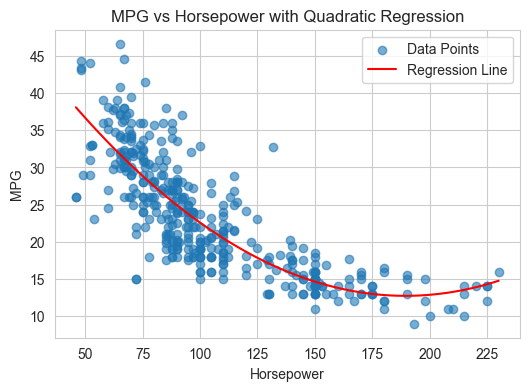

In [17]:
#graph the output of the regression model
# create a grid of horsepower values for plotting the regression line
horsepower_grid = np.linspace(df['horsepower'].min(), df['horsepower'].max
(), 100)
horsepower_grid_squared = horsepower_grid**2
X_grid = pd.DataFrame({'horsepower': horsepower_grid, 'horsepower_squared': horsepower_grid_squared})
X_grid_with_const = sm.add_constant(X_grid)
# predict mpg values using the regression model
mpg_pred = model_weight.predict(X_grid_with_const)
# plot the original data points and the regression line
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'], alpha=0.6, label='Data Points')
plt.plot(horsepower_grid, mpg_pred, color='red', label='Regression Line')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower with Quadratic Regression')
plt.legend()
plt.show()



## Make a prediction! ##

In [18]:
print("Predicted MPG for a car weighing 3000 lbs:", model_weight.predict([1, 3000, 3000**2]))

Predicted MPG for a car weighing 3000 lbs: [9733.15611683]


In [34]:
# add a cubic term to capture even more complex relationship
X = df['horsepower']
X_squared = X**2
X_cubic = X**3
X = pd.DataFrame({'horsepower': X, 'horsepower_squared': X_squared, 'horsepower_cubic': X_cubic })
Y = df['mpg']
X_with_const = sm.add_constant(X)
model_cubic = sm.OLS(Y,X_with_const).fit()
print(model_cubic.summary())



                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     285.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           8.41e-98
Time:                        11:57:36   Log-Likelihood:                -1132.8
No. Observations:                 392   AIC:                             2274.
Df Residuals:                     388   BIC:                             2289.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 60.6848      4

### Assessing the cubic model and interpreting the coefficients

The cubic regression model is:

$$
\widehat{mpg} = 60.6848 - 0.5689(\text{horsepower}) + 0.002079(\text{horsepower}^2) - 0.000002147(\text{horsepower}^3)
$$

Model fit:

- $R^2 = 0.6882$
- Adjusted $R^2 = 0.6858$
- F-statistic $= 285.4807$
- Prob(F-statistic) $= 8.41 \times 10^{-98}$

Coefficient output from the cubic model:

- Intercept: coef $= 60.6848$, std err $= 4.5634$, $t = 13.2980$, $p < 0.001$
- Horsepower: coef $= -0.5689$, std err $= 0.1179$, $t = -4.8239$, $p < 0.001$
- Horsepower squared: coef $= 0.002079$, std err $= 0.000948$, $t = 2.1932$, $p = 0.0289$
- Horsepower cubic: coef $= -0.000002147$, std err $= 0.000002378$, $t = -0.9026$, $p = 0.3673$

Interpretation:

- The model explains about **68.8%** of the variation in MPG.
- The linear and squared horsepower terms are statistically significant, so the relationship is not purely linear.
- The cubic term is **not** statistically significant, which means the extra cubic curvature is not strongly supported by the data.
- Overall, horsepower is still a strong predictor of MPG, but the cubic term does not add much beyond the lower-order terms.

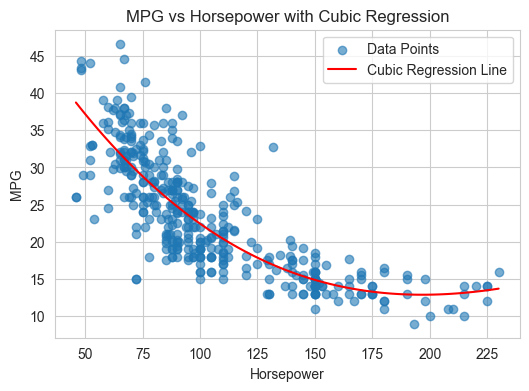

In [35]:
# graph the output of the cubic regression model
horsepower_grid = np.linspace(df['horsepower'].min(), df['horsepower'].max
(), 100)
horsepower_grid_squared = horsepower_grid**2
horsepower_grid_cubic = horsepower_grid**3
X_grid = pd.DataFrame({'horsepower': horsepower_grid, 'horsepower_squared': horsepower_grid_squared, 'horsepower_cubic': horsepower_grid_cubic})
X_grid_with_const = sm.add_constant(X_grid)
mpg_pred_cubic = model_cubic.predict(X_grid_with_const)
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'], alpha=0.6, label='Data Points')
plt.plot(horsepower_grid, mpg_pred_cubic, color='red', label='Cubic Regression Line')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower with Cubic Regression')
plt.legend()
plt.show()


## Linear Regression Modelling with MPG as Target Var. & Acceleration as Predictor Variable

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Pipeline: Polynomial Transform followed by OLS
pipe = Pipeline(steps=[
    ('poly', PolynomialFeatures()),
    ('model', LinearRegression())
])

# 2. Define Parameter Grid (degrees 1-5)
param_grid = {'poly__degree': [1, 2, 3, 4, 5,6,7,8,9,10]}

# 3. Initialize Grid Search
search = GridSearchCV(pipe, param_grid, scoring='neg_mean_squared_error', cv=5)

# 4. Fit to Data
X= df[['horsepower']]
Y = df['mpg']
search.fit(X, Y)

print(search.best_params_)

{'poly__degree': 6}


In [44]:
# run the model with the best degree
best_degree = search.best_params_['poly__degree']
poly = PolynomialFeatures(degree=best_degree)
X_poly = poly.fit_transform(X)
model_final = sm.OLS(Y, X_poly).fit()
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     176.6
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.13e-97
Time:                        12:29:56   Log-Likelihood:                -1127.9
No. Observations:                 392   AIC:                             2268.
Df Residuals:                     386   BIC:                             2292.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1204      0.020      5.999      0.0

**Selecting the best subset of variables**

Forward Selection:
Start with no predictors in the model, then add variables one at a time. At each step, choose the variable that improves the model the most based on a metric such as $R^2$, or cross-validation error. Stop when adding more variables no longer gives a meaningful improvement.

Backward Selection:
Start with all candidate predictors in the model, then remove variables one at a time. At each step, drop the least useful variable, often the one with the highest p-value or the smallest contribution to model quality. Stop when the remaining variables all make a useful contribution.

Both methods are used to build a simpler linear regression model that keeps the most important predictors while avoiding unnecessary variables.

In [ ]:
# 